# 03 — Model 2: Custom CNN (Residual + Depthwise-Separable blocks) on Log-Mel Spectrograms
**Owner:** Gaurav Venigalla

**Input:** output of notebook `01_data_preprocessing` (**Add Input → Your Work → Notebooks**).
**Accelerator:** GPU T4 ×1 (Settings → Accelerator). Full run ≈ 5–10 min.

**Architecture (designed from scratch, ~0.1 M parameters):**
`Conv3×3 stem → 4 × ResDS-block (stride 2) → Global Avg Pool → Dropout → Linear(3)`
where a **ResDS-block** = [depthwise 3×3 → BN → ReLU → pointwise 1×1 → BN → ReLU] × 2 + 1×1 projection shortcut + Squeeze-Excitation.
Depthwise-separable convolutions cut parameters/FLOPs ~8× vs standard convs (smartphone-deployable); residual shortcuts keep gradients healthy.

**Training:** class-weighted cross-entropy (+ label smoothing) for imbalance, **SpecAugment** (time & frequency masking), random time-roll, AdamW + cosine LR, early stopping on validation macro-F1.
**Optuna** search is included (set `RUN_OPTUNA = True`) — preliminary results below use the default hyperparameters.

In [1]:
import os, glob, json, time, copy, random, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)
warnings.filterwarnings("ignore")

SEED = 42
def seed_all(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_all()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

INPUT_DIR = os.environ.get("INPUT_DIR", "/kaggle/input")
WORK_DIR  = os.environ.get("WORK_DIR", "/kaggle/working")
FIG_DIR = os.path.join(WORK_DIR, "figures"); os.makedirs(FIG_DIR, exist_ok=True)
EPOCHS = int(os.environ.get("EPOCHS", 40))
RUN_OPTUNA, N_TRIALS = False, 15

def find(name):
    hits = glob.glob(os.path.join(INPUT_DIR, "**", name), recursive=True) + glob.glob(os.path.join(WORK_DIR, name))
    assert hits, f"{name} not found — add the 01_data_preprocessing notebook output as input"
    return hits[0]

meta = pd.read_csv(find("segments_meta.csv"))
X = np.load(find("logmel.npy")).astype(np.float32)          # (N, 64 mels, T frames), dB in [-80, 0]
cfg = json.load(open(find("prep_config.json")))
CLASSES = cfg["classes"]
y = meta["label"].values
tr, va, te = (meta.split == "train").values, (meta.split == "val").values, (meta.split == "test").values
MU, SD = X[tr].mean(), X[tr].std()                           # normalisation stats from TRAIN only
X = (X - MU) / SD
print(X.shape, {s: int(m.sum()) for s, m in zip(["train", "val", "test"], [tr, va, te])})

device: cuda
(6891, 64, 251) {'train': 4407, 'val': 1650, 'test': 834}


## Dataset with SpecAugment

In [2]:
class SpecDS(Dataset):
    def __init__(self, X, y, train=False, n_fmask=2, f_w=8, n_tmask=2, t_w=25):
        self.X, self.y, self.train = X, y, train
        self.n_fmask, self.f_w, self.n_tmask, self.t_w = n_fmask, f_w, n_tmask, t_w
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        x = self.X[i].copy()
        if self.train:
            x = np.roll(x, np.random.randint(x.shape[1]), axis=1)          # random time shift (cyclic)
            for _ in range(self.n_fmask):                                   # frequency masking
                w = np.random.randint(0, self.f_w + 1); f0 = np.random.randint(0, x.shape[0] - w + 1)
                x[f0:f0 + w, :] = 0
            for _ in range(self.n_tmask):                                   # time masking
                w = np.random.randint(0, self.t_w + 1); t0 = np.random.randint(0, x.shape[1] - w + 1)
                x[:, t0:t0 + w] = 0
            x = x + np.random.randn(*x.shape).astype(np.float32) * 0.05    # light noise
        return torch.from_numpy(x[None]), torch.tensor(self.y[i], dtype=torch.long)

## Custom CNN architecture

In [3]:
class DSConv(nn.Module):
    """Depthwise-separable conv: depthwise k×k (per-channel) + pointwise 1×1 (channel mixing)."""
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(cin, cin, 3, stride, 1, groups=cin, bias=False)
        self.bn1 = nn.BatchNorm2d(cin)
        self.pw = nn.Conv2d(cin, cout, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(cout)
    def forward(self, x):
        return F.relu(self.bn2(self.pw(F.relu(self.bn1(self.dw(x))))))

class SE(nn.Module):
    def __init__(self, c, r=4):
        super().__init__()
        self.fc1, self.fc2 = nn.Linear(c, max(c // r, 8)), nn.Linear(max(c // r, 8), c)
    def forward(self, x):
        s = torch.sigmoid(self.fc2(F.relu(self.fc1(x.mean((2, 3))))))
        return x * s[:, :, None, None]

class ResDSBlock(nn.Module):
    def __init__(self, cin, cout, stride=2, drop=0.1):
        super().__init__()
        self.c1, self.c2 = DSConv(cin, cout, stride), DSConv(cout, cout, 1)
        self.se = SE(cout)
        self.short = nn.Sequential(nn.Conv2d(cin, cout, 1, stride, bias=False), nn.BatchNorm2d(cout)) \
                     if (cin != cout or stride != 1) else nn.Identity()
        self.drop = nn.Dropout2d(drop)
    def forward(self, x):
        return self.drop(F.relu(self.se(self.c2(self.c1(x))) + self.short(x)))

class CustomCNN(nn.Module):
    def __init__(self, n_classes=3, width=32, drop=0.3, block_drop=0.1):
        super().__init__()
        w = [width, int(width * 1.5), width * 2, width * 3, width * 4]
        self.stem = nn.Sequential(nn.Conv2d(1, w[0], 3, 1, 1, bias=False), nn.BatchNorm2d(w[0]), nn.ReLU())
        self.blocks = nn.Sequential(*[ResDSBlock(w[i], w[i + 1], 2, block_drop) for i in range(4)])
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(drop), nn.Linear(w[-1], n_classes))
    def forward(self, x):
        return self.head(self.blocks(self.stem(x)))

m = CustomCNN()
print(m)
print("trainable parameters:", sum(p.numel() for p in m.parameters() if p.requires_grad))

CustomCNN(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (blocks): Sequential(
    (0): ResDSBlock(
      (c1): DSConv(
        (dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (pw): Conv2d(32, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (c2): DSConv(
        (dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
        (bn1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (pw): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNorm2d(48, eps=1

## Common evaluation helper (identical to Model 1)

In [4]:
def evaluate(y_true, prob, patients=None, name="model"):
    pred = prob.argmax(1)
    p, r, f, _ = precision_recall_fscore_support(y_true, pred, average="macro", zero_division=0)
    res = dict(model=name, acc=accuracy_score(y_true, pred), macro_precision=p, macro_recall=r, macro_f1=f)
    yb, pb, predb = (y_true != 0).astype(int), 1 - prob[:, 0], (pred != 0).astype(int)
    tn, fp, fn, tp = confusion_matrix(yb, predb, labels=[0, 1]).ravel()
    res.update(sensitivity=tp / max(tp + fn, 1), specificity=tn / max(tn + fp, 1),
               binary_f1=f1_score(yb, predb, zero_division=0),
               auroc=roc_auc_score(yb, pb) if len(set(yb)) > 1 else float("nan"))
    if patients is not None:
        dfp = pd.DataFrame(prob).assign(patient=patients, y=y_true).groupby("patient").mean()
        pp, yp = dfp[[0, 1, 2]].values, dfp["y"].values.astype(int)
        res.update(patient_acc=accuracy_score(yp, pp.argmax(1)),
                   patient_macro_f1=f1_score(yp, pp.argmax(1), average="macro", zero_division=0))
    return {k: (round(float(v), 4) if not isinstance(v, str) else v) for k, v in res.items()}

## Training loop

In [5]:
@torch.no_grad()
def predict(model, Xa, bs=256):
    model.eval(); out = []
    for i in range(0, len(Xa), bs):
        xb = torch.from_numpy(Xa[i:i + bs][:, None]).to(DEVICE)
        with torch.autocast(device_type="cuda", enabled=DEVICE == "cuda"):
            out.append(F.softmax(model(xb).float(), 1).cpu().numpy())
    return np.concatenate(out)

def train_model(hp, epochs=EPOCHS, patience=10, verbose=True):
    seed_all()
    model = CustomCNN(width=hp["width"], drop=hp["drop"], block_drop=hp["block_drop"]).to(DEVICE)
    cw = compute_class_weight("balanced", classes=np.arange(3), y=y[tr]) ** hp["cw_power"]
    crit = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float32, device=DEVICE), label_smoothing=0.05)
    opt = torch.optim.AdamW(model.parameters(), lr=hp["lr"], weight_decay=hp["wd"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=DEVICE == "cuda")
    dl = DataLoader(SpecDS(X[tr], y[tr], train=True, f_w=hp["f_w"], t_w=hp["t_w"]), batch_size=hp["bs"],
                    shuffle=True, num_workers=2, drop_last=True)
    hist, best_f1, best_state, bad = [], -1, None, 0
    for ep in range(epochs):
        model.train(); t0, tot = time.time(), 0.0
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            with torch.autocast(device_type="cuda", enabled=DEVICE == "cuda"):
                loss = crit(model(xb), yb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tot += loss.item() * len(yb)
        sched.step()
        pv = predict(model, X[va])
        vf1 = f1_score(y[va], pv.argmax(1), average="macro")
        vloss = F.nll_loss(torch.log(torch.tensor(pv) + 1e-8), torch.tensor(y[va])).item()
        hist.append(dict(epoch=ep + 1, train_loss=tot / len(dl.dataset), val_loss=vloss,
                         val_acc=accuracy_score(y[va], pv.argmax(1)), val_macro_f1=vf1))
        if verbose:
            print(f"ep {ep+1:02d} | train loss {hist[-1]['train_loss']:.4f} | val loss {vloss:.4f} "
                  f"| val acc {hist[-1]['val_acc']:.4f} | val macro-F1 {vf1:.4f} | {time.time()-t0:.1f}s")
        if vf1 > best_f1:
            best_f1, best_state, bad = vf1, copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
            if bad >= patience:
                if verbose: print("early stopping")
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(hist), best_f1

DEFAULT_HP = dict(width=32, drop=0.3, block_drop=0.1, lr=2e-3, wd=1e-3, bs=64, f_w=8, t_w=25, cw_power=1.0)

## (Optional) Optuna hyperparameter search — maximises validation macro-F1

In [6]:
hp = dict(DEFAULT_HP)
if RUN_OPTUNA:
    import optuna
    def objective(trial):
        h = dict(width=trial.suggest_categorical("width", [24, 32, 48]),
                 drop=trial.suggest_float("drop", 0.1, 0.5), block_drop=trial.suggest_float("block_drop", 0.0, 0.2),
                 lr=trial.suggest_float("lr", 3e-4, 5e-3, log=True), wd=trial.suggest_float("wd", 1e-5, 1e-2, log=True),
                 bs=trial.suggest_categorical("bs", [32, 64]), f_w=trial.suggest_int("f_w", 4, 12),
                 t_w=trial.suggest_int("t_w", 10, 40), cw_power=trial.suggest_float("cw_power", 0.5, 1.0))
        return train_model(h, epochs=15, patience=5, verbose=False)[2]
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS)
    hp.update(study.best_params)
    study.trials_dataframe().to_csv(os.path.join(WORK_DIR, "optuna_trials_cnn.csv"), index=False)
    print("best:", study.best_value, study.best_params)
print("using hyperparameters:", hp)

using hyperparameters: {'width': 32, 'drop': 0.3, 'block_drop': 0.1, 'lr': 0.002, 'wd': 0.001, 'bs': 64, 'f_w': 8, 't_w': 25, 'cw_power': 1.0}


In [7]:
model, hist, best_val = train_model(hp)
torch.save(model.state_dict(), os.path.join(WORK_DIR, "custom_cnn_best.pt"))
hist.to_csv(os.path.join(WORK_DIR, "cnn_training_history.csv"), index=False)
print("best val macro-F1:", round(best_val, 4))

ep 01 | train loss 1.2280 | val loss 0.8214 | val acc 0.6285 | val macro-F1 0.3307 | 15.7s
ep 02 | train loss 1.1575 | val loss 0.8787 | val acc 0.5570 | val macro-F1 0.3280 | 3.7s
ep 03 | train loss 1.1093 | val loss 0.9971 | val acc 0.4794 | val macro-F1 0.2876 | 3.6s
ep 04 | train loss 1.0851 | val loss 0.8314 | val acc 0.6188 | val macro-F1 0.3466 | 3.6s
ep 05 | train loss 1.0317 | val loss 0.8842 | val acc 0.5352 | val macro-F1 0.3167 | 3.6s
ep 06 | train loss 1.0037 | val loss 0.7057 | val acc 0.7079 | val macro-F1 0.3936 | 3.6s
ep 07 | train loss 0.9507 | val loss 0.7044 | val acc 0.8139 | val macro-F1 0.5328 | 3.6s
ep 08 | train loss 0.9690 | val loss 0.7788 | val acc 0.7673 | val macro-F1 0.4808 | 3.6s
ep 09 | train loss 0.8959 | val loss 0.7731 | val acc 0.7873 | val macro-F1 0.5003 | 3.6s
ep 10 | train loss 0.9126 | val loss 0.6863 | val acc 0.8218 | val macro-F1 0.5380 | 3.7s
ep 11 | train loss 0.8668 | val loss 0.6574 | val acc 0.8661 | val macro-F1 0.5707 | 3.7s
ep 12 | t

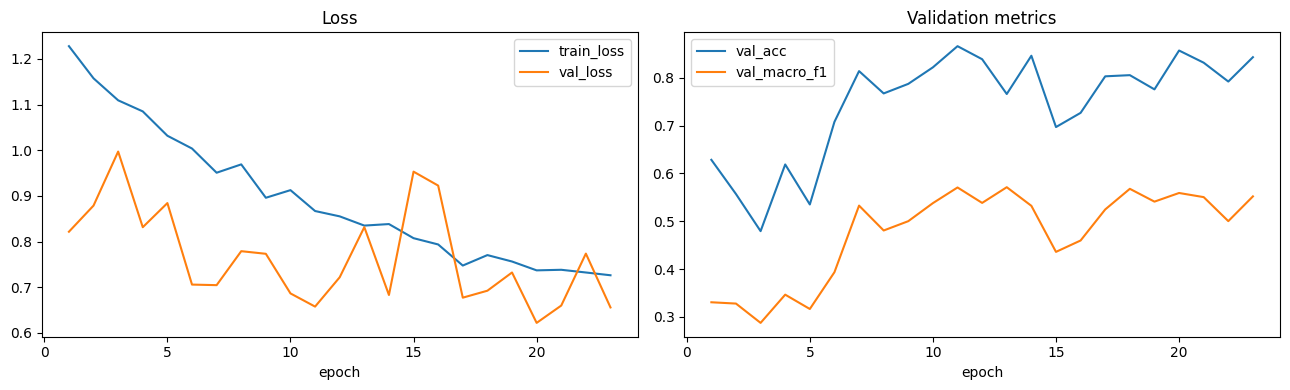

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
hist.plot(x="epoch", y=["train_loss", "val_loss"], ax=ax[0], title="Loss")
hist.plot(x="epoch", y=["val_acc", "val_macro_f1"], ax=ax[1], title="Validation metrics")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "cnn_learning_curves.png"), dpi=130); plt.show()

## Test evaluation (held-out patients)

model             Custom CNN (ResDS)
acc                           0.7974
macro_precision               0.5866
macro_recall                  0.6204
macro_f1                      0.5671
sensitivity                   0.9633
specificity                   0.3939
binary_f1                     0.9421
auroc                         0.6922
patient_acc                   0.6667
patient_macro_f1              0.6429
              precision    recall  f1-score   support

     Healthy       0.59      0.39      0.47        99
     Chronic       0.95      0.87      0.91       683
 Non-chronic       0.22      0.60      0.32        52

    accuracy                           0.80       834
   macro avg       0.59      0.62      0.57       834
weighted avg       0.86      0.80      0.82       834



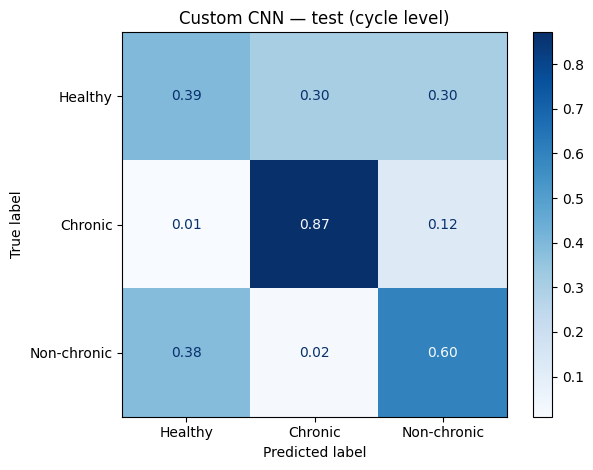

In [9]:
prob = predict(model, X[te])
res = evaluate(y[te], prob, meta.patient.values[te], "Custom CNN (ResDS)")
res_df = pd.DataFrame([res]).set_index("model")
print(res_df.T)
print(classification_report(y[te], prob.argmax(1), labels=range(3), target_names=CLASSES, zero_division=0))
cm = confusion_matrix(y[te], prob.argmax(1), labels=range(3), normalize="true")
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(cmap="Blues", values_format=".2f")
plt.title("Custom CNN — test (cycle level)"); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "cm_custom_cnn.png"), dpi=130); plt.show()

## Error analysis

In [10]:
ev = meta[te].assign(pred=prob.argmax(1), conf=prob.max(1))
ev["correct"] = ev.pred == ev.label
print("Accuracy by device:\n", ev.groupby("device").correct.agg(["mean", "size"]).round(3))
print("\nAccuracy by cycle annotation:\n", ev.groupby("cycle_label").correct.agg(["mean", "size"]).round(3))
print("\nAccuracy by diagnosis:\n", ev.groupby("diagnosis").correct.agg(["mean", "size"]).round(3))
print("\nMean confidence — correct vs wrong:\n", ev.groupby("correct").conf.mean().round(3))

Accuracy by device:
            mean  size
device               
AKGC417L  0.856   611
Litt3200  1.000    61
LittC2SE  1.000    11
Meditron  0.464   151

Accuracy by cycle annotation:
               mean  size
cycle_label             
both         0.727    66
crackle      0.946   203
normal       0.749   474
wheeze       0.769    91

Accuracy by diagnosis:
             mean  size
diagnosis             
COPD       0.871   683
Healthy    0.394    99
LRTI       0.583    24
URTI       0.607    28

Mean confidence — correct vs wrong:
 correct
False    0.572
True     0.602
Name: conf, dtype: float32


## Combined comparison table (if Model 1 results are attached as input)

In [11]:
res_df.to_csv(os.path.join(WORK_DIR, "results_model2_cnn.csv"))
tables = [res_df]
c1 = glob.glob(os.path.join(INPUT_DIR, "**", "results_model1_classical.csv"), recursive=True)
if c1:
    tables.insert(0, pd.read_csv(c1[0]).set_index("model"))
comparison = pd.concat(tables)
comparison.to_csv(os.path.join(WORK_DIR, "comparison_table.csv"))
print(comparison.to_string())

                       acc  macro_precision  macro_recall  macro_f1  sensitivity  specificity  binary_f1   auroc  patient_acc  patient_macro_f1
model                                                                                                                                          
SVM (RBF)           0.8945           0.7727        0.7083    0.6787       0.9932       0.2727     0.9499  0.9172       0.6667            0.6556
Random Forest       0.8645           0.8022        0.5465    0.5738       0.9973       0.1010     0.9416  0.8760       0.4444            0.4485
XGBoost             0.8945           0.7794        0.6824    0.6544       0.9946       0.1818     0.9451  0.9166       0.5556            0.5242
Custom CNN (ResDS)  0.7974           0.5866        0.6204    0.5671       0.9633       0.3939     0.9421  0.6922       0.6667            0.6429
